In [9]:
#Student Success Predictor -Pass or Fail (multiple components)
#STEPS-1)Load and understand the data
import pandas as pd

df=pd.read_csv("C:\\Users\\Tavish\\Downloads\\Pass-Fail Data.csv")
print("Sample Rows")
print(df.head())

print("DataSet Shape")
print(f'Rows:{df.shape[0]},Columns:{df.shape[1]}')

print("Dataset info")
print(df.info())

print("Summary stats")
print(df.describe(include='all'))

print("Missing Values")
print(df.isnull().sum())



Sample Rows
   student_id  attendance_pct  homework_pct  midterm_score  \
0           1              95            92             88   
1           2              88            85             79   
2           3              60            55             58   
3           4              72            70             65   
4           5              40            45             50   

   study_hours_per_week pass internet  
0                    12  Yes      Yes  
1                    10  Yes      Yes  
2                     4  Yes      Yes  
3                     6  Yes      Yes  
4                     3  Yes      Yes  
DataSet Shape
Rows:100,Columns:7
Dataset info
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null  

In [20]:
#Step 2
#Preprocessing the data(Clean)-machine can read only numeric ddata ,so we have to convert categorical into numeric
#fot this wee have to convert those colmn with object values to integer, and we also have to ensure that it should not contain any missing values or invalid values

import pandas as pd
from sklearn.preprocessing import LabelEncoder

df=pd.read_csv(r"C:\Users\Tavish\OneDrive\Documents\Pass-Fail Data_ml.csv")

print("Missing valeues in each colmn")
print(df.isnull().sum())

le=LabelEncoder()
df['Internet']=le.fit_transform(df["Internet"]) #yes-1,no-0
df['Passed']=le.fit_transform(df["Passed"])

print("After Encoding")
print(df.head())

print("Data-Types after cleaning")
print(df.dtypes)

Missing valeues in each colmn
student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
Passed                  0
Internet                0
dtype: int64
After Encoding
   student_id  attendance_pct  homework_pct  midterm_score  \
0           1              95            92             88   
1           2              88            85             79   
2           3              60            55             58   
3           4              72            70             65   
4           5              40            45             50   

   study_hours_per_week  Passed  Internet  
0                    12       1         1  
1                    10       1         1  
2                     4       1         1  
3                     6       1         1  
4                     3       1         1  
Data-Types after cleaning
student_id              int64
attendance_pct          int64
homework_pct            int64
midterm

Classification Report
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        16
           1       0.00      0.00      0.00         4

    accuracy                           0.80        20
   macro avg       0.40      0.50      0.44        20
weighted avg       0.64      0.80      0.71        20



C:\Users\Tavish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Tavish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Tavish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

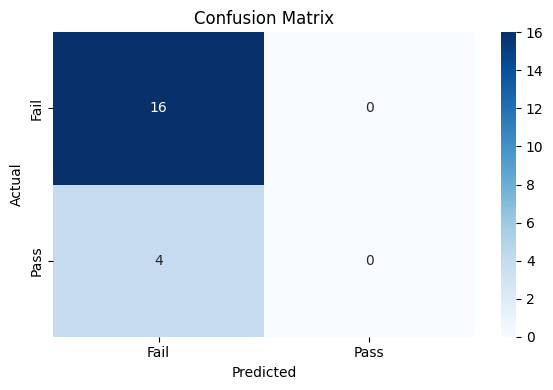

-----Predict your Result----


Enter study hours: 4
Enter attendance: 56
Enter homework: 78
Enter midterm score: 89


Prediction Based on Input: Fail


C:\Users\Tavish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [31]:
#Step3-feature scaling(StandardScaler or MinMaxScaler)
#Step4-split the data- divide the given data into training part and testing part
#step5-train the model
#step6-make predictions of testing part
#step7-evaluate the model
#step8-visualize results
#step9-improve/experiment
#step10-save your every step

import pandas as pd #used for handling datasets
import numpy as np #used for numerical operations
from sklearn.preprocessing import StandardScaler,LabelEncoder #labelencoder converts text into numbers and standardscaler normalizes numerical values
from sklearn.model_selection import train_test_split #used to divide data into training data and testing data
from sklearn.linear_model import LogisticRegression #used for binary classification(pass or fail prediction)
from sklearn.metrics import classification_report,confusion_matrix#used to evaluate model performance
import matplotlib.pyplot as plt #data visualization
import seaborn as sns #data visualization

df=pd.read_csv(r"C:\Users\Tavish\Downloads\Pass-Fail_Data_ml_filled.csv")

le=LabelEncoder() #converts text into numbers
df['Internet']=le.fit_transform(df["Internet"]) #yes-1,no-0 bcoz machine learning model can't understand text
df['Passed']=le.fit_transform(df["Passed"])

#normalising numeric columns
features=['attendance_pct','homework_pct','midterm_score','study_hours_per_week'] #scaling is done on these colmns,these are input features for prediction
scaler=StandardScaler() #normalize data
df_scaled=df.copy() #copy is created so that the original data remains unchanged
df_scaled[features]=scaler.fit_transform(df[features]) #fit calculates mean and std. deviation and transform applies scaling formula to calculate z_score,df.copy is represented by df_scaled and inside features it contains all the columns that are going to be scaled for prediction

#step4-training and testing by split
X=df_scaled[features] #input for prediction
y=df_scaled['Passed'] #target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42) #train,test split,80 percent for training and 20 for testing,random_state=42 ensures same split every time

#step5-train the model
model=LogisticRegression() #creates logistic regression model
model.fit(X_train,y_train) #model learns patterns from training data

#step6-make predictions
y_pred=model.predict(X_test)

print("Classification Report")
print(classification_report(y_test,y_pred)) #shows accuracy,precision,recall,f1_score

conf_matrix=confusion_matrix(y_test,y_pred)#show correct and incorrect predictions
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix,annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])#annot=true show numbers,fmt="d" represents integer format and cmap displays blue color theme

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout() #for adjusting spacing
plt.show()

#user prediction section
print("-----Predict your Result----")
try:
    study_hours_per_week=float(input("Enter study hours:"))
    attendance_pct =float(input("Enter attendance:"))
    homework_pct=float(input("Enter homework:"))
    midterm_score=float(input("Enter midterm score:"))

    user_input_df=pd.DataFrame([{
    'attendance_pct':attendance_pct,
    'homework_pct':homework_pct,
    'midterm_score':midterm_score,
    'study_hours_per_week':study_hours_per_week
}])

    user_input_scaled=scaler.transform(user_input_df) #appplies scaling for training
    prediction=model.predict(user_input_scaled)[0] #predicting
    result="Pass" if prediction ==1 else "Fail" 
    print(f"Prediction Based on Input: {result}")
    
except Exception as e:
    print("An error occured",e)
    

    
    
    













